# 🏋️ Biomechanical 3D Squat Analysis Pipeline

This notebook processes raw 2D video of squats and extracts broadcast-quality, anatomically accurate 3D joint angles using a stateless tracking approach and a Dual-stream Spatio-temporal Transformer (MotionBERT).

**Pipeline Architecture:**
1. **Extraction:** YOLOv8 (Stateless + Center-Weighted Attention) extracts 2D COCO keypoints.
2. **Transformation (Healing):** Pandas performs time-series imputation to heal missing bounding box data.
3. **3D Lifting:** MotionBERT (DSTformer) calculates Z-axis depth using AMASS kinematic pre-training.
4. **Biomechanical Calculation:** 3D coordinates are converted into physical joint angles (degrees) via vector dot products.

# STEP 1: ENVIRONMENT & GLOBAL CONFIGURATION

In [15]:
!pip install --quiet --no-warn-script-location ultralytics opencv-python-headless numpy torch torchvision fastdtw transformers lapx pandas matplotlib

import sys
import os
import json
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
from transformers import CLIPTokenizer, CLIPTextModel
from tqdm.auto import tqdm
import shutil
from google.colab import drive
import subprocess
import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

# --- GLOBAL PIPELINE FILTER ---
# Add specific filenames here to only process those videos (e.g., ["anatomy.mp4", "IMG_123.MOV"]).
# Leave the list empty [] to process ALL videos in the input directories.
TARGET_VIDEOS = []

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# ---------------------------------------------------------
# UPDATE THIS PATH TO YOUR ACTUAL SHARED DRIVE FOLDER
# ---------------------------------------------------------
BASE_PATH = Path("/content/drive/MyDrive/ITCS 4152 5010")

# Setup directory structure variables
input_dir = BASE_PATH / "Data"
output_video_dir = BASE_PATH / "outputs/annotate_videos"
output_keypoint_dir = BASE_PATH / "outputs/keypoints"
output_standardized_dir = BASE_PATH / "outputs/standardized_2d_keypoints"
output_motionbert_dir = BASE_PATH / "outputs/motionbert_keypoints"
output_angles_dir = BASE_PATH / "outputs/angles_csv"

if not input_dir.exists():
    print(f"ERROR: Cannot find {input_dir}. Check your BASE_PATH.")

# Create directories if they don't exist
# output_video_dir.mkdir(parents=True, exist_ok=True)
# output_keypoint_dir.mkdir(parents=True, exist_ok=True)
# output_standardized_dir.mkdir(parents=True, exist_ok=True)
# output_motionbert_dir.mkdir(parents=True, exist_ok=True)
# output_angles_dir.mkdir(parents=True, exist_ok=True)

# Clone MotionBERT
if not os.path.exists('/content/MotionBERT'):
    !git clone https://github.com/Walter0807/MotionBERT.git
if "/content/MotionBERT" not in sys.path:
    sys.path.append("/content/MotionBERT")

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Compute Device Active: {device}")

Mounted at /content/drive
Compute Device Active: cuda


## Step 2: Stateless 2D Pose Extraction (YOLOv8)
This step processes the raw video frame-by-frame. It uses a **Stateless** approach (`model.predict` instead of `model.track`) paired with a center-weighted spatial scoring algorithm to prevent the bounding box from hallucinating or locking onto background gym equipment.

In [16]:
RELEVANT_FOLDERS = ["original data", "golden reference"]
yolo_model = YOLO("yolov8m-pose.pt")
yolo_model.to('cuda')
VIDEO_EXTENSIONS = {".mp4", ".mov", ".avi", ".mkv"}

COCO_SKELETON = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)]

def log(msg):
    print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] {msg}")

def get_video_fps(video_path: Path) -> float:
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return float(fps) if fps and fps > 0 else 30.0

def compute_hard_attention_scores(xyxy: np.ndarray, confs: np.ndarray, width: float, height: float) -> np.ndarray:
    areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
    center_x, center_y = width / 2.0, height / 2.0
    max_dist = np.sqrt(center_x**2 + center_y**2)
    box_centers_x = (xyxy[:, 0] + xyxy[:, 2]) / 2.0
    box_centers_y = (xyxy[:, 1] + xyxy[:, 3]) / 2.0
    distances = np.sqrt((box_centers_x - center_x)**2 + (box_centers_y - center_y)**2)
    proximity_scores = 1.0 - (distances / max_dist)
    return (areas * 0.4) * (confs * 0.2) * (proximity_scores * 0.4)

def select_primary_index(scores: np.ndarray) -> int | None:
    if scores.size == 0: return None
    return int(np.argmax(scores))

def draw_primary_subject(frame: np.ndarray, box: np.ndarray, keypoints_xy: np.ndarray, keypoints_conf: np.ndarray, min_kpt_conf: float) -> None:
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(frame, (x1, y1), (x2, y2), (60, 180, 255), 2)
    cv2.putText(frame, "Primary Subject", (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (60, 180, 255), 2, cv2.LINE_AA)
    for i, (x, y) in enumerate(keypoints_xy):
        if keypoints_conf[i] < min_kpt_conf: continue
        cv2.circle(frame, (int(x), int(y)), 4, (0, 220, 255), -1)
    for a, b in COCO_SKELETON:
        if keypoints_conf[a] < min_kpt_conf or keypoints_conf[b] < min_kpt_conf: continue
        cv2.line(frame, (int(keypoints_xy[a][0]), int(keypoints_xy[a][1])), (int(keypoints_xy[b][0]), int(keypoints_xy[b][1])), (0, 255, 80), 2)

def process_video(model: YOLO, optimized_video_path: Path, output_video_path: Path, output_keypoint_path: Path, conf: float, kpt_conf: float) -> None:
    all_frames: list[dict] = []
    frame_idx = 0
    fps = get_video_fps(optimized_video_path)
    writer = None

    results_stream = model.predict(source=str(optimized_video_path), stream=True, conf=conf, imgsz=1280, half=True, verbose=False, device="cuda:0")

    for result in results_stream:
        frame = result.orig_img.copy()
        height, width = frame.shape[:2]
        if writer is None: writer = cv2.VideoWriter(str(output_video_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

        frame_data = {"frame": frame_idx, "people": []}
        primary_box, primary_keypoints_xy, primary_keypoints_conf = None, None, None

        if result.boxes is not None and len(result.boxes) > 0:
            xyxy = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            scores = compute_hard_attention_scores(xyxy, confs, width, height)
            primary_index = select_primary_index(scores)

            if primary_index is not None and result.keypoints is not None:
                primary_box = xyxy[primary_index]
                primary_keypoints_xy = result.keypoints.xy[primary_index].cpu().numpy()
                primary_keypoints_conf = result.keypoints.conf[primary_index].cpu().numpy() if result.keypoints.conf is not None else np.ones(primary_keypoints_xy.shape[0], dtype=float)

        if primary_box is not None and primary_keypoints_xy is not None and primary_keypoints_conf is not None:
            draw_primary_subject(frame, primary_box, primary_keypoints_xy, primary_keypoints_conf, kpt_conf)
            person_data = {"person_id": 0, "keypoints": []}
            for joint_idx in range(len(primary_keypoints_xy)):
                person_data["keypoints"].append({"joint_id": joint_idx, "x": float(primary_keypoints_xy[joint_idx][0]), "y": float(primary_keypoints_xy[joint_idx][1]), "confidence": float(primary_keypoints_conf[joint_idx])})
            frame_data["people"].append(person_data)

        if writer is not None: writer.write(frame)
        all_frames.append(frame_data)
        frame_idx += 1
        if frame_idx % 100 == 0: print(f"    > Progress: {frame_idx} frames processed...")

    if writer is not None: writer.release()
    with output_keypoint_path.open("w", encoding="utf-8") as f: json.dump(all_frames, f, indent=2)

# --- BATCH LOOP WITH GLOBAL FILTER ---
log(f"Scanning directory: {input_dir}")
video_files = [p for p in input_dir.rglob("*") if p.suffix.lower() in VIDEO_EXTENSIONS and p.parent.name in RELEVANT_FOLDERS]

if TARGET_VIDEOS:
    video_files = [p for p in video_files if p.name in TARGET_VIDEOS]

# Generate target stems so downstream steps only process these specific files
target_stems = [f"{p.parent.name.lower()}__{p.stem}" for p in video_files]

if not video_files:
    log(f"ERROR: No videos found matching TARGET_VIDEOS or in folders {RELEVANT_FOLDERS}.")
else:
    log(f"Found {len(video_files)} videos. Starting pipeline...")
    for video_path in tqdm(video_files, desc="YOLO Extraction"):
        label = video_path.parent.name.lower()
        stem = f"{label}__{video_path.stem}"
        output_keypoint_path = output_keypoint_dir / f"{stem}_keypoints.json"
        output_video_path = output_video_dir / f"{stem}_annotated.mp4"

        log(f"--- PROCESSING: {stem} ---")
        local_video_path = f"/content/temp_{video_path.name}"
        optimized_video_path = f"/content/optimized_{video_path.stem}.mp4"
        shutil.copy(video_path, local_video_path)

        try:
            subprocess.run(["ffmpeg", "-y", "-i", local_video_path, "-vf", "scale=-2:720", "-r", "15", "-c:v", "libx264", "-preset", "ultrafast", "-an", optimized_video_path], check=True, capture_output=True, text=True, timeout=300)
        except Exception as e:
            log(f"  !! FFMPEG FAILED: {stem}")
            if os.path.exists(local_video_path): os.remove(local_video_path)
            continue

        log("  Tracking & Writing Annotated Video...")
        process_video(model=yolo_model, optimized_video_path=Path(optimized_video_path), output_video_path=output_video_path, output_keypoint_path=output_keypoint_path, conf=0.4, kpt_conf=0.4)
        os.remove(local_video_path)
        os.remove(optimized_video_path)

[14:42:41] Scanning directory: /content/drive/MyDrive/ITCS 4152 5010/Data
[14:42:43] Found 24 videos. Starting pipeline...


YOLO Extraction:   0%|          | 0/24 [00:00<?, ?it/s]

[14:42:43] --- PROCESSING: original data__Copy of IMG_8566 ---
[14:42:46]   Tracking & Writing Annotated Video...
[14:42:51] --- PROCESSING: original data__Copy of IMG_8557 ---
[14:42:54]   Tracking & Writing Annotated Video...
[14:42:56] --- PROCESSING: original data__Copy of IMG_8561 ---
[14:42:58]   Tracking & Writing Annotated Video...
[14:43:00] --- PROCESSING: original data__Copy of IMG_8542 ---
[14:43:05]   Tracking & Writing Annotated Video...
[14:43:08] --- PROCESSING: original data__Copy of Copy of IMG_8557 ---
[14:43:11]   Tracking & Writing Annotated Video...
[14:43:13] --- PROCESSING: original data__Copy of Copy of IMG_6991 ---
[14:45:44]   Tracking & Writing Annotated Video...
    > Progress: 100 frames processed...
    > Progress: 200 frames processed...
[14:45:57] --- PROCESSING: original data__Copy of Copy of IMG_6997 ---
[14:49:44]   Tracking & Writing Annotated Video...
    > Progress: 100 frames processed...
    > Progress: 200 frames processed...
    > Progress: 30

## Step 3: Data Healing & Standardization (Pandas Imputation)
Because YOLO is a 2D bounding box model, it occasionally misses body parts due to background camouflage or clothing (e.g., chopping off the head). This step reads the raw JSON, identifies missing joints using the confidence score, and uses Pandas time-series interpolation to heal the gaps before saving the data as a clean 3D Tensor `(Time, 17, 3)`.

In [17]:
json_files = list(output_keypoint_dir.rglob("*.json"))

# Filter to only process our targeted stems
if 'target_stems' in globals() and target_stems:
    json_files = [p for p in json_files if p.stem.replace("_keypoints", "") in target_stems]

print(f"Found {len(json_files)} targeted JSON files. Healing data...")

num_joints = 17
confidence_threshold = 0.2

for j_path in json_files:
    with j_path.open("r", encoding="utf-8") as f:
        frames = json.load(f)

    T = len(frames)
    if T == 0: continue

    sequence_array = np.full((T, num_joints, 3), np.nan, dtype=np.float32)

    for t, frame in enumerate(frames):
        people = frame.get("people", [])
        if people and people[0].get("person_id") == 0:
            for joint in people[0].get("keypoints", []):
                j_id = int(joint.get("joint_id", -1))
                conf = float(joint.get("confidence", 0.0))
                if 0 <= j_id < num_joints and conf >= confidence_threshold:
                    sequence_array[t, j_id, 0] = joint.get("x", np.nan)
                    sequence_array[t, j_id, 1] = joint.get("y", np.nan)
                    sequence_array[t, j_id, 2] = conf

    # Time-series healing
    for j_id in range(num_joints):
        df = pd.DataFrame(sequence_array[:, j_id, :2], columns=['x', 'y'])
        df = df.interpolate(method='linear', limit_direction='both').bfill().ffill()
        sequence_array[:, j_id, 0] = df['x'].values
        sequence_array[:, j_id, 1] = df['y'].values
        mask = np.isnan(sequence_array[:, j_id, 2])
        sequence_array[mask, j_id, 2] = 0.5

    sequence_array = np.nan_to_num(sequence_array, nan=0.0)
    out_path = output_standardized_dir / f"{j_path.stem}.npy"
    np.save(out_path, sequence_array)
    print(f"Healed: {j_path.stem} -> Shape {sequence_array.shape}")

Found 24 targeted JSON files. Healing data...
Healed: original data__Copy of IMG_8566_keypoints -> Shape (51, 17, 3)
Healed: original data__Copy of IMG_8557_keypoints -> Shape (67, 17, 3)
Healed: original data__Copy of IMG_8561_keypoints -> Shape (66, 17, 3)
Healed: original data__Copy of IMG_8542_keypoints -> Shape (73, 17, 3)
Healed: original data__Copy of Copy of IMG_8557_keypoints -> Shape (67, 17, 3)
Healed: original data__Copy of Copy of IMG_6991_keypoints -> Shape (229, 17, 3)
Healed: original data__Copy of Copy of IMG_6997_keypoints -> Shape (339, 17, 3)
Healed: original data__Copy of Copy of IMG_7005_keypoints -> Shape (231, 17, 3)
Healed: original data__Copy of Copy of IMG_9777_keypoints -> Shape (135, 17, 3)
Healed: original data__Copy of IMG_9794_keypoints -> Shape (109, 17, 3)
Healed: original data__Copy of IMG_8586_keypoints -> Shape (86, 17, 3)
Healed: original data__Copy of IMG_9769_keypoints -> Shape (138, 17, 3)
Healed: original data__Copy of IMG_8574_keypoints -> Sha

## Step 4: MotionBERT 3D Lifting (DSTformer)
This step replaces standard 2D-to-3D math with a Dual-stream Spatio-temporal Transformer. Because MotionBERT was pre-trained on millions of frames of dynamic human motion (AMASS), it contains a strong kinematic prior. It calculates the Z-axis depth accurately by interpreting the momentum and foreshortening of the YOLO 2D coordinates.

In [18]:
from lib.model.DSTformer import DSTformer

WEIGHTS_FILE_NAME = "MB_ft_h36m.bin"
weights_path = BASE_PATH / "Data" / WEIGHTS_FILE_NAME

npy_files = list(output_standardized_dir.rglob("*.npy"))
if 'target_stems' in globals() and target_stems:
    npy_files = [p for p in npy_files if p.stem.replace("_keypoints", "") in target_stems]

print(f"Running MotionBERT on {len(npy_files)} files...")

motionbert_model = DSTformer(dim_in=3, dim_out=3, dim_feat=512, dim_rep=512, depth=5, num_heads=8, mlp_ratio=2, maxlen=243, num_joints=17).to(device)

print(f"Loading weights from {weights_path}...")
try:
    checkpoint = torch.load(weights_path, map_location=device, weights_only=False)
    state_dict = checkpoint.get('model_pos', checkpoint.get('model', checkpoint))
    clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    motionbert_model.load_state_dict(clean_state_dict, strict=False)
    motionbert_model.eval()
except Exception as e:
    print(f"CRITICAL ERROR loading weights: {e}")
    raise e

def convert_coco_to_h36m(coco_points):
    T = coco_points.shape[0]
    h36m = np.zeros((T, 17, 3), dtype=np.float32)

    # Direct mappings
    h36m[:, 1] = coco_points[:, 12]; h36m[:, 2] = coco_points[:, 14]; h36m[:, 3] = coco_points[:, 16]
    h36m[:, 4] = coco_points[:, 11]; h36m[:, 5] = coco_points[:, 13]; h36m[:, 6] = coco_points[:, 15]
    h36m[:, 9] = coco_points[:, 0];  h36m[:, 11] = coco_points[:, 5]; h36m[:, 12] = coco_points[:, 7]
    h36m[:, 13] = coco_points[:, 9]; h36m[:, 14] = coco_points[:, 6]; h36m[:, 15] = coco_points[:, 8]; h36m[:, 16] = coco_points[:, 10]

    # Calculated mappings
    h36m[:, 0] = (coco_points[:, 11] + coco_points[:, 12]) / 2.0
    h36m[:, 8] = (coco_points[:, 5] + coco_points[:, 6]) / 2.0
    h36m[:, 7] = (h36m[:, 0] + h36m[:, 8]) / 2.0
    h36m[:, 10] = h36m[:, 9] + (h36m[:, 9] - h36m[:, 8]) * 0.2
    return h36m

for npy_path in tqdm(npy_files, desc="MotionBERT Inference"):
    sequence_2d = np.load(npy_path)
    T = sequence_2d.shape[0]

    h36m_2d = convert_coco_to_h36m(sequence_2d)

    # Center Pelvis (Isolate X/Y so we don't subtract confidence)
    for t in range(T):
        pelvis_xy = h36m_2d[t, 0, :2].copy()
        h36m_2d[t, :, :2] = (h36m_2d[t, :, :2] - pelvis_xy) / 1000.0

    pad_size = 121
    padded_2d = np.concatenate([np.repeat(h36m_2d[0:1], pad_size, axis=0), h36m_2d, np.repeat(h36m_2d[-1:], pad_size, axis=0)], axis=0)

    predicted_3d_frames = []
    for i in range(T):
        window = torch.tensor(padded_2d[i : i + 243], dtype=torch.float32).unsqueeze(0).contiguous().to(device)
        with torch.no_grad():
            out_3d = motionbert_model(window).squeeze().cpu().numpy()
        predicted_3d_frames.append(out_3d[121] if len(out_3d.shape) == 3 else out_3d)

    final_3d_array = np.stack(predicted_3d_frames, axis=0)
    save_path = output_motionbert_dir / npy_path.name
    np.save(save_path, final_3d_array)
    print(f"Saved Lifted Pose: {save_path.name}")

Running MotionBERT on 24 files...
Loading weights from /content/drive/MyDrive/ITCS 4152 5010/Data/MB_ft_h36m.bin...


MotionBERT Inference:   0%|          | 0/24 [00:00<?, ?it/s]

Saved Lifted Pose: golden reference__G003_side_keypoints.npy
Saved Lifted Pose: golden reference__G002_45_keypoints.npy
Saved Lifted Pose: golden reference__G001_side_keypoints.npy
Saved Lifted Pose: golden reference__G004_side_keypoints.npy
Saved Lifted Pose: golden reference__G005_45_keypoints.npy
Saved Lifted Pose: original data__Copy of IMG_8561_keypoints.npy
Saved Lifted Pose: original data__Copy of IMG_8557_keypoints.npy
Saved Lifted Pose: original data__Copy of IMG_8542_keypoints.npy
Saved Lifted Pose: original data__Copy of Copy of IMG_6997_keypoints.npy
Saved Lifted Pose: original data__Copy of Copy of IMG_6991_keypoints.npy
Saved Lifted Pose: original data__Copy of Copy of IMG_7005_keypoints.npy
Saved Lifted Pose: original data__Copy of IMG_8566_keypoints.npy
Saved Lifted Pose: original data__Copy of Copy of IMG_9777_keypoints.npy
Saved Lifted Pose: original data__Copy of Copy of IMG_8557_keypoints.npy
Saved Lifted Pose: original data__Copy of IMG_8574_keypoints.npy
Saved Lif

## Step 5: Diagnostic Plotting
Visualizes a single frame of the processed pipeline. Compares the original 2D output (mapped to Human3.6M format) against the final 3D generated projection.

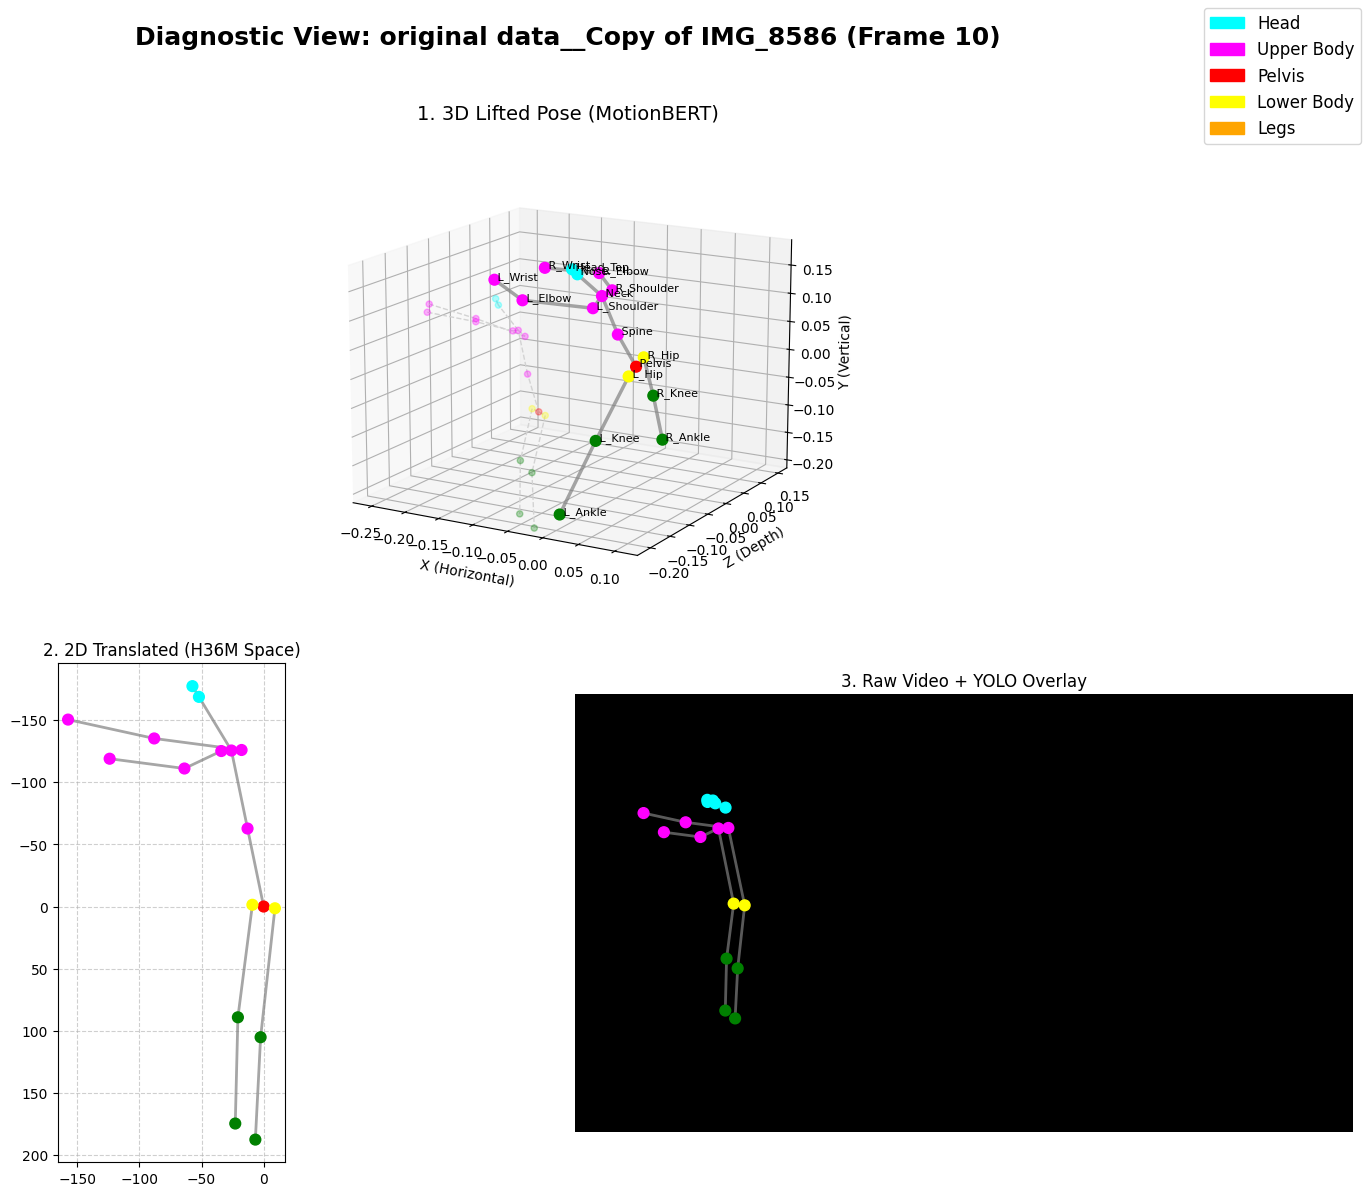

In [19]:
# Use the first target stem as our diagnostic target
DIAGNOSTIC_STEM = target_stems[10] if 'target_stems' in globals() and target_stems else "incorrect__anatomy"
FRAME_IDX = 10

video_path = BASE_PATH / "Data" / DIAGNOSTIC_STEM.split("__")[0] / f"{DIAGNOSTIC_STEM.split('__')[1]}.mp4"
standardized_2d_path = output_standardized_dir / f"{DIAGNOSTIC_STEM}_keypoints.npy"
motionbert_path = output_motionbert_dir / f"{DIAGNOSTIC_STEM}_keypoints.npy"

# Definitions & Colors
JOINT_NAMES = ["Pelvis", "R_Hip", "R_Knee", "R_Ankle", "L_Hip", "L_Knee", "L_Ankle", "Spine", "Neck", "Nose", "Head_Top", "L_Shoulder", "L_Elbow", "L_Wrist", "R_Shoulder", "R_Elbow", "R_Wrist"]
H36M_BONES = [(0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6), (0, 7), (7, 8), (8, 9), (9, 10), (8, 11), (11, 12), (12, 13), (8, 14), (14, 15), (15, 16)]
COCO_BONES = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)]

H36M_COLORS = np.array(['gray'] * 17, dtype=object)
H36M_COLORS[[9, 10]] = 'cyan'; H36M_COLORS[[7, 8, 11, 12, 13, 14, 15, 16]] = 'magenta'
H36M_COLORS[[0]] = 'red'; H36M_COLORS[[1, 4]] = 'yellow'; H36M_COLORS[[2, 3, 5, 6]] = 'green'
COCO_COLORS = np.array(['gray'] * 17, dtype=object)
COCO_COLORS[[0, 1, 2, 3, 4]] = 'cyan'; COCO_COLORS[[5, 6, 7, 8, 9, 10]] = 'magenta'
COCO_COLORS[[11, 12]] = 'yellow'; COCO_COLORS[[13, 14, 15, 16]] = 'green'

def plot_diagnostic_3d(ax, sequence_3d, frame_idx):
    kpts = sequence_3d[frame_idx]
    width_x, height_y, depth_z = kpts[:, 0], -kpts[:, 1], kpts[:, 2] # Y-axis inverted for viewing

    ax.scatter(width_x, depth_z, height_y, c=H36M_COLORS, s=60, alpha=1.0, zorder=5)
    for joint1, joint2 in H36M_BONES: ax.plot([width_x[joint1], width_x[joint2]], [depth_z[joint1], depth_z[joint2]], [height_y[joint1], height_y[joint2]], c='gray', linewidth=2.5, alpha=0.7)
    for i, name in enumerate(JOINT_NAMES): ax.text(width_x[i], depth_z[i], height_y[i], f" {name}", size=8, color='black')

    back_wall_depth = np.min(depth_z) - (np.max(depth_z) - np.min(depth_z)) * 0.2
    ax.scatter(width_x, np.full_like(depth_z, back_wall_depth), height_y, c=H36M_COLORS, s=20, alpha=0.3)
    for joint1, joint2 in H36M_BONES: ax.plot([width_x[joint1], width_x[joint2]], [back_wall_depth, back_wall_depth], [height_y[joint1], height_y[joint2]], c='lightgray', linewidth=1, linestyle='--')

    ax.set_xlabel('X (Horizontal)'); ax.set_ylabel('Z (Depth)'); ax.set_zlabel('Y (Vertical)')
    max_range = np.array([width_x.max()-width_x.min(), depth_z.max()-depth_z.min(), height_y.max()-height_y.min()]).max() / 2.0
    mid_x, mid_depth, mid_y = (width_x.max()+width_x.min())*0.5, (depth_z.max()+depth_z.min())*0.5, (height_y.max()+height_y.min())*0.5
    margin = max_range * 1.1
    ax.set_xlim(mid_x - margin, mid_x + margin); ax.set_ylim(mid_depth - margin, mid_depth + margin); ax.set_zlim(mid_y - margin, mid_y + margin)

# Load & Prep
motionbert_data = np.load(str(motionbert_path))
standardized_sequence_2d = np.load(str(standardized_2d_path))

h36m_2d_sequence = convert_coco_to_h36m(standardized_sequence_2d)
kpts_2d_h36m = h36m_2d_sequence[FRAME_IDX]
pelvis_xy = kpts_2d_h36m[0, :2].copy()
kpts_2d_h36m[:, :2] = kpts_2d_h36m[:, :2] - pelvis_xy

cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_IDX)
ret, frame = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((720, 1280, 3), dtype=np.uint8)

orig_h, orig_w = frame_rgb.shape[:2]
kpts_raw_yolo = standardized_sequence_2d[FRAME_IDX].copy()
kpts_raw_yolo[:, :2] *= (orig_h / 720.0)

# Plotting
fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"Diagnostic View: {DIAGNOSTIC_STEM} (Frame {FRAME_IDX})", fontsize=18, fontweight='bold')

ax1 = fig.add_subplot(2, 2, (1, 2), projection='3d')
plot_diagnostic_3d(ax1, motionbert_data, FRAME_IDX)
ax1.view_init(elev=15, azim=-60)
ax1.set_title("1. 3D Lifted Pose (MotionBERT)", fontsize=14)

ax2 = fig.add_subplot(2, 2, 3)
ax2.scatter(kpts_2d_h36m[:, 0], kpts_2d_h36m[:, 1], c=H36M_COLORS, s=60, zorder=5)
for joint1, joint2 in H36M_BONES: ax2.plot([kpts_2d_h36m[joint1, 0], kpts_2d_h36m[joint2, 0]], [kpts_2d_h36m[joint1, 1], kpts_2d_h36m[joint2, 1]], c='gray', linewidth=2, alpha=0.7)
ax2.invert_yaxis(); ax2.set_aspect('equal'); ax2.set_title("2. 2D Translated (H36M Space)", fontsize=12); ax2.grid(True, linestyle='--', alpha=0.6)

ax3 = fig.add_subplot(2, 2, 4)
ax3.imshow(frame_rgb)
ax3.scatter(kpts_raw_yolo[:, 0], kpts_raw_yolo[:, 1], c=COCO_COLORS, s=60, zorder=5)
for joint1, joint2 in COCO_BONES:
    if kpts_raw_yolo[joint1, 2] > 0.1 and kpts_raw_yolo[joint2, 2] > 0.1:
        ax3.plot([kpts_raw_yolo[joint1, 0], kpts_raw_yolo[joint2, 0]], [kpts_raw_yolo[joint1, 1], kpts_raw_yolo[joint2, 1]], c='gray', linewidth=2, alpha=0.7)
ax3.set_title("3. Raw Video + YOLO Overlay", fontsize=12); ax3.axis('off')

fig.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(['cyan','magenta','red','yellow','orange'], ['Head','Upper Body','Pelvis','Lower Body','Legs'])], loc='upper right', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Step 6: Extract Joint Angles (The Handoff)
Converts the final 3D root-relative vectors into real-world angles (in degrees) for the final PyTorch comparison model.

In [20]:
# 1. Grab all the MotionBERT 3D output files
angle_npy_files = list(output_motionbert_dir.rglob("*.npy"))

# 2. Filter by global TARGET_VIDEOS if defined
if 'target_stems' in globals() and target_stems:
    angle_npy_files = [p for p in angle_npy_files if p.stem.replace("_keypoints", "") in target_stems]

print(f"Extracting 3D joint angles for {len(angle_npy_files)} files...")

ANGLE_TRIPLETS = {
    "Right_Knee": (1, 2, 3),
    "Left_Knee":  (4, 5, 6),
    "Right_Hip":  (7, 1, 2),
    "Left_Hip":   (7, 4, 5),
    "Spine_Lean": (8, 7, 0)
}

def calculate_3d_angles_over_time(sequence, joint_a, joint_b, joint_c):
    A, B, C = sequence[:, joint_a, :], sequence[:, joint_b, :], sequence[:, joint_c, :]
    BA, BC = A - B, C - B
    dot_product = np.sum(BA * BC, axis=1)

    # Add a tiny epsilon to prevent division-by-zero if joints perfectly overlap
    norm_BA = np.maximum(np.linalg.norm(BA, axis=1), 1e-6)
    norm_BC = np.maximum(np.linalg.norm(BC, axis=1), 1e-6)

    cosine_angle = np.clip(dot_product / (norm_BA * norm_BC), -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

# 3. Batch Process the Files
for npy_path in tqdm(angle_npy_files, desc="Calculating Angles"):
    sequence_3d = np.load(npy_path)
    T = sequence_3d.shape[0]

    angle_data = {"Frame": np.arange(T)}
    for angle_name, (a, b, c) in ANGLE_TRIPLETS.items():
        angle_data[angle_name] = calculate_3d_angles_over_time(sequence_3d, a, b, c)

    df_angles = pd.DataFrame(angle_data)

    # Generate clean output name based on the original video stem
    stem_name = npy_path.stem.replace("_keypoints", "")
    output_csv_path = output_angles_dir / f"{stem_name}_angles.csv"

    df_angles.to_csv(output_csv_path, index=False)

print(f"\nAll 3D angles successfully saved to: {output_angles_dir}")

# Preview the last processed file as a sanity check
if len(angle_npy_files) > 0:
    print(f"\nPreview of {stem_name}_angles.csv:")
    print(df_angles.head())

Extracting 3D joint angles for 24 files...


Calculating Angles:   0%|          | 0/24 [00:00<?, ?it/s]


All 3D angles successfully saved to: /content/drive/MyDrive/ITCS 4152 5010/outputs/angles_csv

Preview of original data__Copy of Copy of IMG_9978_angles.csv:
   Frame  Right_Knee   Left_Knee   Right_Hip    Left_Hip  Spine_Lean
0      0  163.159561  168.686295  164.236664  168.185287  176.233963
1      1  163.042831  168.323044  163.629089  167.878220  176.379593
2      2  162.455078  167.830109  162.401215  167.375076  176.356583
3      3  161.984497  166.821457  161.403992  166.448196  176.696838
4      4  160.270020  165.499435  160.041306  165.181519  177.056824


In [21]:
# ==========================================
# STEP 7: ML DATASET PREPARATION (REPS & AUGMENTATION)
# ==========================================

import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# 1. Setup Directories
output_model_ready_dir = BASE_PATH / "outputs/model_ready_reps"
output_model_ready_dir.mkdir(parents=True, exist_ok=True)

csv_files = list(output_angles_dir.rglob("*.csv"))
print(f"Processing {len(csv_files)} angle CSVs for model extraction...")

# Features we actually want to feed the model (excluding 'Frame')
FEATURES = ["Right_Knee", "Left_Knee", "Right_Hip", "Left_Hip", "Spine_Lean"]
TARGET_FRAMES = 41

# Augmentation Multipliers (How many synthetic reps to make per real rep)
GOLDEN_AUGMENT_COUNT = 10

def get_dynamic_bounds(knee_angles, hole_idx, max_search=45):
    """Searches backward and forward up to 3 seconds (45 frames) to find the standing peaks."""
    # Search backward for the highest point (start of descent)
    left_bound = max(0, hole_idx - max_search)
    start_idx = left_bound + np.argmax(knee_angles[left_bound:hole_idx+1])

    # Search forward for the highest point (end of ascent)
    right_bound = min(len(knee_angles), hole_idx + max_search + 1)
    end_idx = hole_idx + np.argmax(knee_angles[hole_idx:right_bound])

    return start_idx, end_idx

def extract_and_warp_dynamic(df, start_idx, end_idx, target_length=TARGET_FRAMES):
    """Extracts the exact physical rep and resamples it to 41 frames."""
    raw_slice = df.iloc[start_idx:end_idx+1][FEATURES].values

    # Time Warping: Resample whatever length we grabbed into exactly 41 frames
    T_orig = raw_slice.shape[0]

    # Prevent crashing if the bounds are perfectly identical (0-frame rep)
    if T_orig < 2:
        return None

    x_old = np.linspace(0, 1, T_orig)
    x_new = np.linspace(0, 1, target_length)

    interpolator = interp1d(x_old, raw_slice, axis=0, kind='linear')
    warped_slice = interpolator(x_new)

    return warped_slice

rep_counter = 0

for csv_path in csv_files:
    # Determine Label (1 for Correct/Golden, 0 for Incorrect/Ordinary)
    is_golden = "golden reference" in csv_path.stem.lower()
    label = 1 if is_golden else 0

    df = pd.read_csv(csv_path)
    if df.empty: continue

    # Find the bottom of the squats (Local minima of the knee angle)
    # We invert the knee angle so the "hole" becomes a peak.
    # Prominence=20 ensures we don't accidentally select tiny knee twitches while standing.
    inverted_knee = -df['Right_Knee'].values
    peaks, _ = find_peaks(inverted_knee, distance=30, prominence=20)

for hole_idx in peaks:
        # --- 1. Find the true start and end of the squat ---
        normal_knee = df['Right_Knee'].values
        start_idx, end_idx = get_dynamic_bounds(normal_knee, hole_idx)

        # --- 2. Extract and Warp ---
        base_rep = extract_and_warp_dynamic(df, start_idx, end_idx, target_length=TARGET_FRAMES)

        if base_rep is None:
            continue

        # --- THE FIX: Range of Motion (ROM) Guardrail ---
        knee_max = np.max(base_rep[:, 0])
        knee_min = np.min(base_rep[:, 0])

        if (knee_max - knee_min) < 40.0:
            continue

        # Save the base rep
        save_name = f"{csv_path.stem}__hole_{hole_idx}__label_{label}.npy"
        np.save(output_model_ready_dir / save_name, base_rep)
        rep_counter += 1

        # --- 3. Augment if it's Golden Data ---
        if is_golden:
            for _ in range(GOLDEN_AUGMENT_COUNT):
                # To augment, we randomly shift the bounds to simulate slightly
                # earlier starts or later finishes, changing the tempo!
                shift_start = start_idx + np.random.randint(-5, 6)
                shift_end = end_idx + np.random.randint(-5, 6)

                # Keep bounds inside the video
                shift_start = max(0, shift_start)
                shift_end = min(len(df)-1, shift_end)

                warped_rep = extract_and_warp_dynamic(df, shift_start, shift_end, target_length=TARGET_FRAMES)
                if warped_rep is None: continue

                noise = np.random.normal(0, 1.5, warped_rep.shape)
                augmented_rep = warped_rep + noise

                save_name = f"{csv_path.stem}__hole_{hole_idx}__label_{label}_aug_{rep_counter}.npy"
                np.save(output_model_ready_dir / save_name, augmented_rep)
                rep_counter += 1

print(f"\n✅ Successfully extracted {rep_counter} model-ready (41, 5) tensors to {output_model_ready_dir}")

Processing 24 angle CSVs for model extraction...

✅ Successfully extracted 120 model-ready (41, 5) tensors to /content/drive/MyDrive/ITCS 4152 5010/outputs/model_ready_reps


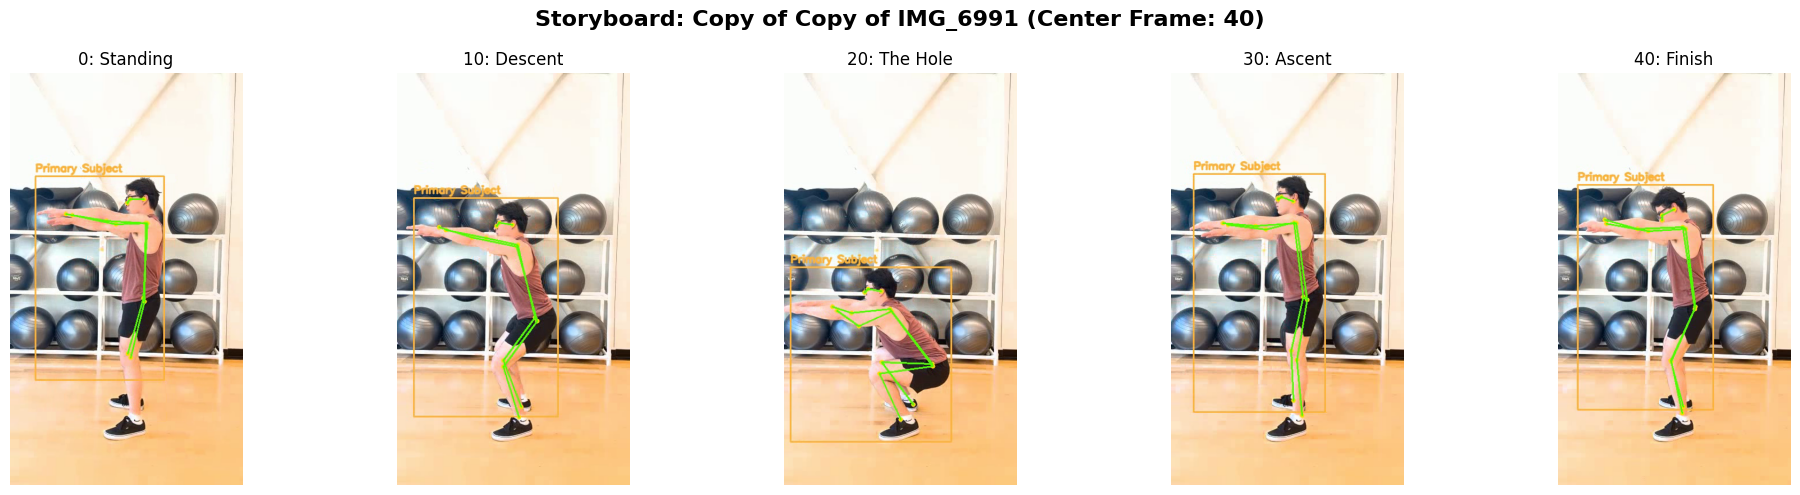

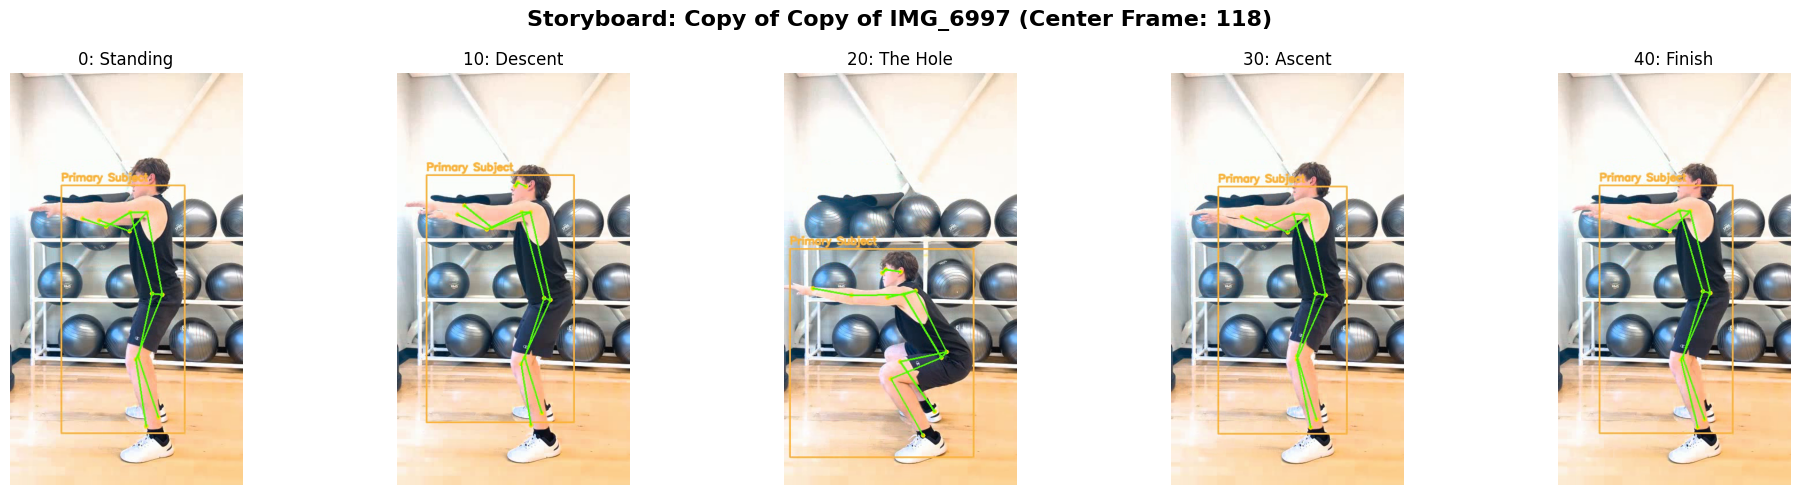

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

output_model_ready_dir = BASE_PATH / "outputs/model_ready_reps"
# Grab only the base reps (we don't need to visualize the augmented jitter)
npy_files = list(output_model_ready_dir.glob("*__hole_*__label_*.npy"))
npy_files = [f for f in npy_files if "_aug_" not in f.name]

if not npy_files:
    print("No base rep files found. Ensure you updated the naming convention in Cell 13!")
else:
    # Pick 2 random reps to visualize
    sample_files = random.sample(npy_files, min(2, len(npy_files)))

    for npy_path in sample_files:
        # 1. Parse the Data Lineage from the filename
        # Example: correct__mindbodysoul_angles__hole_142__label_1.npy
        filename_parts = npy_path.stem.split("__")

        original_folder = filename_parts[0] # "correct" or "incorrect"
        # Remove the "_angles" suffix we added during the CSV creation
        original_video_stem = filename_parts[1].replace("_angles", "")

        # Extract the exact frame index where the bottom of the squat occurred
        hole_string = filename_parts[2] # "hole_142"
        hole_idx = int(hole_string.split("_")[1])

        # 2. Locate the 15-FPS Annotated video
        # We use the annotated video because it is strictly 15 FPS, matching the CSV rows exactly.
        annotated_video_name = f"{original_folder}__{original_video_stem}_annotated.mp4"
        video_path = output_video_dir / annotated_video_name

        if not video_path.exists():
            print(f"Could not find 15 FPS video at {video_path}")
            continue

        # 3. Extract the 5 Key Frames
        # Our 41-frame tensor is [hole - 20, hole - 10, hole, hole + 10, hole + 20]
        frame_targets = [hole_idx - 20, hole_idx - 10, hole_idx, hole_idx + 10, hole_idx + 20]
        titles = ["0: Standing", "10: Descent", "20: The Hole", "30: Ascent", "40: Finish"]

        extracted_images = []
        cap = cv2.VideoCapture(str(video_path))

        for f_idx in frame_targets:
            # Prevent seeking to negative frames if the squat happened right at the start
            safe_f_idx = max(0, f_idx)
            cap.set(cv2.CAP_PROP_POS_FRAMES, safe_f_idx)
            ret, frame = cap.read()
            if ret:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                extracted_images.append(frame_rgb)
            else:
                extracted_images.append(np.zeros((720, 1280, 3), dtype=np.uint8))

        cap.release()

        # 4. Plot the Storyboard
        fig, axes = plt.subplots(1, 5, figsize=(20, 5))
        fig.suptitle(f"Storyboard: {original_video_stem} (Center Frame: {hole_idx})", fontsize=16, fontweight='bold')

        for i, (ax, img, title) in enumerate(zip(axes, extracted_images, titles)):
            ax.imshow(img)
            ax.set_title(title, fontsize=12)
            ax.axis('off')

            # Put a red border around the center frame (The Hole)
            if i == 2:
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(5)
                    spine.set_visible(True)

        plt.tight_layout()
        plt.show()

In [ ]:
# Also running some diagnostic animations to showcase the model
# ==========================================
# STEP 5: ANIMATED VISUAL DIAGNOSTICS
# ==========================================

from matplotlib.animation import FuncAnimation
import matplotlib.patches as mpatches

# 1. Setup new output directory for the videos
output_diagnostic_videos_dir = BASE_PATH / "outputs/diagnostic_videos"
output_diagnostic_videos_dir.mkdir(parents=True, exist_ok=True)

# 2. Gather target files
npy_files = list(output_motionbert_dir.rglob("*.npy"))
if 'target_stems' in globals() and target_stems:
    npy_files = [p for p in npy_files if p.stem.replace("_keypoints", "") in target_stems]

print(f"Preparing to render {len(npy_files)} diagnostic videos. This may take a few minutes per video...")

# Definitions & Colors
JOINT_NAMES = ["Pelvis", "R_Hip", "R_Knee", "R_Ankle", "L_Hip", "L_Knee", "L_Ankle", "Spine", "Neck", "Nose", "Head_Top", "L_Shoulder", "L_Elbow", "L_Wrist", "R_Shoulder", "R_Elbow", "R_Wrist"]
H36M_BONES = [(0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6), (0, 7), (7, 8), (8, 9), (9, 10), (8, 11), (11, 12), (12, 13), (8, 14), (14, 15), (15, 16)]
COCO_BONES = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)]

H36M_COLORS = np.array(['gray'] * 17, dtype=object)
H36M_COLORS[[9, 10]] = 'cyan'; H36M_COLORS[[7, 8, 11, 12, 13, 14, 15, 16]] = 'magenta'
H36M_COLORS[[0]] = 'red'; H36M_COLORS[[1, 4]] = 'yellow'; H36M_COLORS[[2, 3, 5, 6]] = 'green'

COCO_COLORS = np.array(['gray'] * 17, dtype=object)
COCO_COLORS[[0, 1, 2, 3, 4]] = 'cyan'; COCO_COLORS[[5, 6, 7, 8, 9, 10]] = 'magenta'
COCO_COLORS[[11, 12]] = 'yellow'; COCO_COLORS[[13, 14, 15, 16]] = 'green'

def create_diagnostic_animation(stem_name):
    print(f"\nRendering animation for: {stem_name}...")

    # Define paths
    original_label = stem_name.split("__")[0]
    original_name = stem_name.split("__")[1]
    video_path = BASE_PATH / "Data" / original_label / f"{original_name}.mp4"

    standardized_2d_path = output_standardized_dir / f"{stem_name}_keypoints.npy"
    motionbert_path = output_motionbert_dir / f"{stem_name}_keypoints.npy"
    output_mp4_path = output_diagnostic_videos_dir / f"{stem_name}_diagnostic.mp4"

    # Load Data
    motionbert_data = np.load(str(motionbert_path))
    standardized_sequence_2d = np.load(str(standardized_2d_path))
    h36m_2d_sequence = convert_coco_to_h36m(standardized_sequence_2d)

    T = min(motionbert_data.shape[0], h36m_2d_sequence.shape[0])

    # Video Setup
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0 or np.isnan(fps): fps = 30.0

    # Calculate Global 3D Limits to lock the camera
    global_x = motionbert_data[:, :, 0]
    global_y = -motionbert_data[:, :, 1]
    global_z = motionbert_data[:, :, 2]

    max_range = np.array([global_x.max()-global_x.min(), global_z.max()-global_z.min(), global_y.max()-global_y.min()]).max() / 2.0
    mid_x = (global_x.max()+global_x.min())*0.5
    mid_z = (global_z.max()+global_z.min())*0.5
    mid_y = (global_y.max()+global_y.min())*0.5
    margin = max_range * 1.1

    # Figure Setup
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(f"Diagnostic Tracking: {stem_name}", fontsize=18, fontweight='bold')

    ax1 = fig.add_subplot(2, 2, (1, 2), projection='3d')
    ax2 = fig.add_subplot(2, 2, 3)
    ax3 = fig.add_subplot(2, 2, 4)

    # The Animation Loop
    def update(frame_idx):
        ax1.clear(); ax2.clear(); ax3.clear()

        # --- PANEL 1: 3D MotionBERT ---
        kpts_3d = motionbert_data[frame_idx]
        width_x, height_y, depth_z = kpts_3d[:, 0], -kpts_3d[:, 1], kpts_3d[:, 2]

        ax1.scatter(width_x, depth_z, height_y, c=H36M_COLORS, s=60, zorder=5)
        for j1, j2 in H36M_BONES: ax1.plot([width_x[j1], width_x[j2]], [depth_z[j1], depth_z[j2]], [height_y[j1], height_y[j2]], c='gray', linewidth=2.5)

        back_wall = global_z.min() - margin * 0.2
        ax1.scatter(width_x, np.full_like(depth_z, back_wall), height_y, c=H36M_COLORS, s=20, alpha=0.3)
        for j1, j2 in H36M_BONES: ax1.plot([width_x[j1], width_x[j2]], [back_wall, back_wall], [height_y[j1], height_y[j2]], c='lightgray', linewidth=1, linestyle='--')

        ax1.view_init(elev=15, azim=-60)
        ax1.set_xlim(mid_x - margin, mid_x + margin); ax1.set_ylim(mid_z - margin, mid_z + margin); ax1.set_zlim(mid_y - margin, mid_y + margin)
        ax1.set_xlabel('X'); ax1.set_ylabel('Z'); ax1.set_zlabel('Y'); ax1.set_title("1. 3D Lifted Pose (MotionBERT)")

        # --- PANEL 2: 2D H36M Translated ---
        kpts_2d_h36m = h36m_2d_sequence[frame_idx].copy()
        pelvis_xy = kpts_2d_h36m[0, :2].copy()
        kpts_2d_h36m[:, :2] -= pelvis_xy

        ax2.scatter(kpts_2d_h36m[:, 0], kpts_2d_h36m[:, 1], c=H36M_COLORS, s=60, zorder=5)
        for j1, j2 in H36M_BONES: ax2.plot([kpts_2d_h36m[j1, 0], kpts_2d_h36m[j2, 0]], [kpts_2d_h36m[j1, 1], kpts_2d_h36m[j2, 1]], c='gray', linewidth=2)
        ax2.invert_yaxis(); ax2.set_aspect('equal'); ax2.set_title("2. 2D Translated (H36M Space)"); ax2.grid(True, linestyle='--', alpha=0.6)

        # --- PANEL 3: Raw Video + Overlay ---
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((720, 1280, 3), dtype=np.uint8)
        orig_h, orig_w = frame_rgb.shape[:2]

        kpts_raw_yolo = standardized_sequence_2d[frame_idx].copy()
        kpts_raw_yolo[:, :2] *= (orig_h / 720.0)

        ax3.imshow(frame_rgb)
        ax3.scatter(kpts_raw_yolo[:, 0], kpts_raw_yolo[:, 1], c=COCO_COLORS, s=60, zorder=5)
        for j1, j2 in COCO_BONES:
            if kpts_raw_yolo[j1, 2] > 0.1 and kpts_raw_yolo[j2, 2] > 0.1:
                ax3.plot([kpts_raw_yolo[j1, 0], kpts_raw_yolo[j2, 0]], [kpts_raw_yolo[j1, 1], kpts_raw_yolo[j2, 1]], c='gray', linewidth=2)
        ax3.set_title("3. Raw Video + YOLO Overlay"); ax3.axis('off')

    # Legend
    fig.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(['cyan','magenta','red','yellow','orange'], ['Head','Upper Body','Pelvis','Lower Body','Legs'])], loc='upper right', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Compile and Save
    anim = FuncAnimation(fig, update, frames=T, interval=1000/fps)
    anim.save(output_mp4_path, writer='ffmpeg', fps=fps)
    plt.close(fig)
    cap.release()
    print(f"✅ Video saved to: {output_mp4_path}")

# Run the generator
for npy_path in npy_files:
    stem_name = npy_path.stem.replace("_keypoints", "")
    create_diagnostic_animation(stem_name)

print("\n🎉 All diagnostic animations complete!")

Preparing to render 24 diagnostic videos. This may take a few minutes per video...

Rendering animation for: golden reference__G003_side...
✅ Video saved to: /content/drive/MyDrive/ITCS 4152 5010/outputs/diagnostic_videos/golden reference__G003_side_diagnostic.mp4

Rendering animation for: golden reference__G002_45...
✅ Video saved to: /content/drive/MyDrive/ITCS 4152 5010/outputs/diagnostic_videos/golden reference__G002_45_diagnostic.mp4

Rendering animation for: golden reference__G001_side...
✅ Video saved to: /content/drive/MyDrive/ITCS 4152 5010/outputs/diagnostic_videos/golden reference__G001_side_diagnostic.mp4

Rendering animation for: golden reference__G004_side...
✅ Video saved to: /content/drive/MyDrive/ITCS 4152 5010/outputs/diagnostic_videos/golden reference__G004_side_diagnostic.mp4

Rendering animation for: golden reference__G005_45...
✅ Video saved to: /content/drive/MyDrive/ITCS 4152 5010/outputs/diagnostic_videos/golden reference__G005_45_diagnostic.mp4

Rendering anim